# Transformer Architecture: Encoder

## Introduction
- The key components of Transformer:
  - Self-Attention
  - Multi-Head Attention
  - Positional Encoding
  - Layer Normalization  
- These concepts form the foundation of Transformers. Once they are clear, we can move into the full architecture.

## A High-Level Look
- Let’s begin by looking at the model as a single black box. In a machine translation application, it would take a sentence in one language, and output its translation in another.

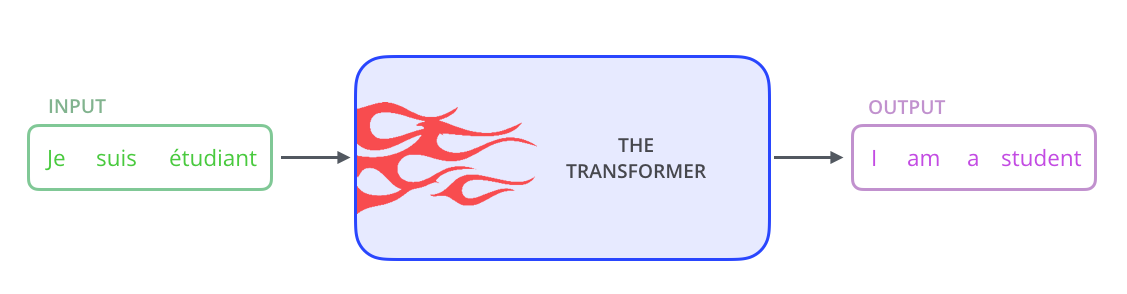

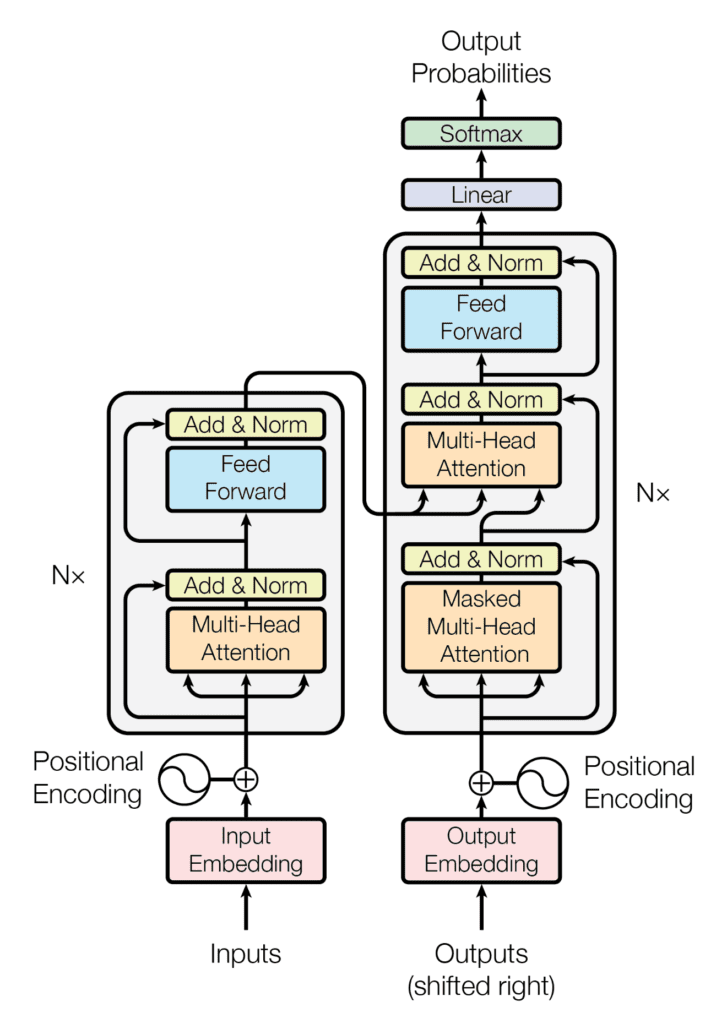

## Transformer Overview
- The Transformer architecture has **two main parts**:
  1. **Encoder**
  2. **Decoder**
- In this session, the focus is on the **Encoder** part.
- The architecture diagram can look complex, but it can be simplified.

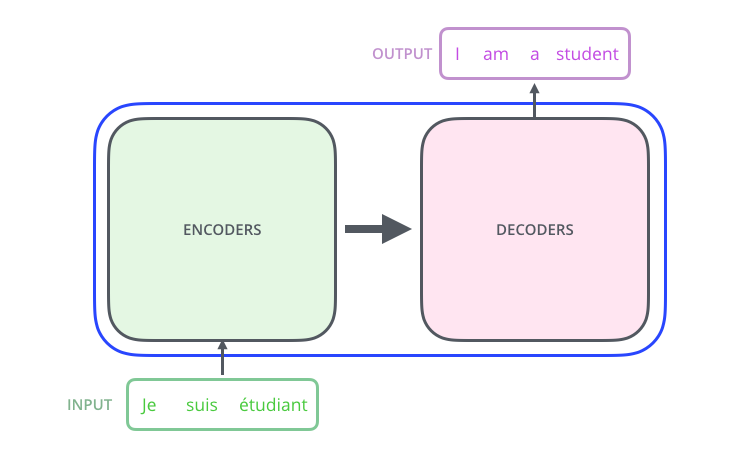

## The Encoder
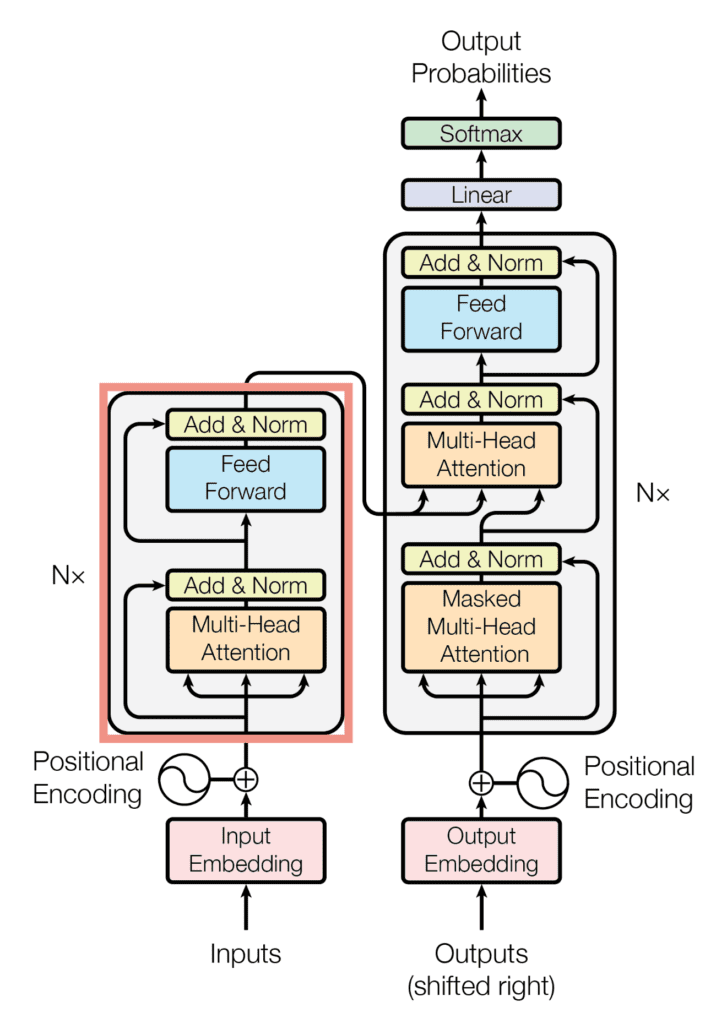

### Simplified Representation
- A Transformer can be visualized as a box containing two smaller boxes:
  - Encoder
  - Decoder  
- Both encoder and decoder are made up of **multiple identical blocks**.
- In the original *“Attention is All You Need”* paper:
  - Encoder = 6 identical blocks
  - Decoder = 6 identical blocks  
- These numbers are not fixed; they were chosen based on experimental results.

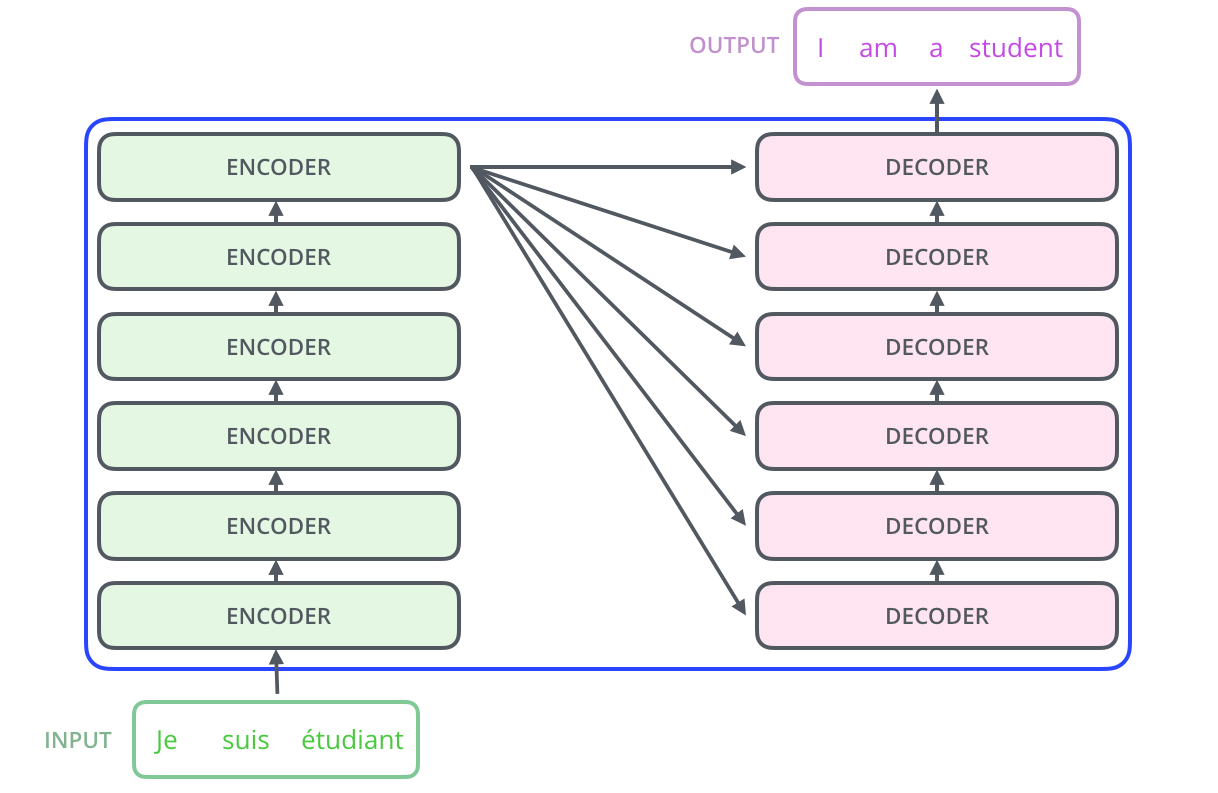

## Encoder Structure
- Each **encoder block** contains two main components:
  1. **Self-Attention Module (Multi-Head Attention)**
  2. **Feed-Forward Neural Network (FFNN)**

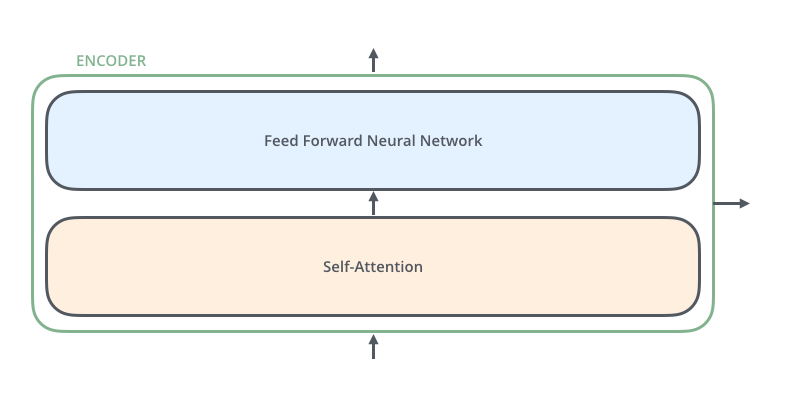

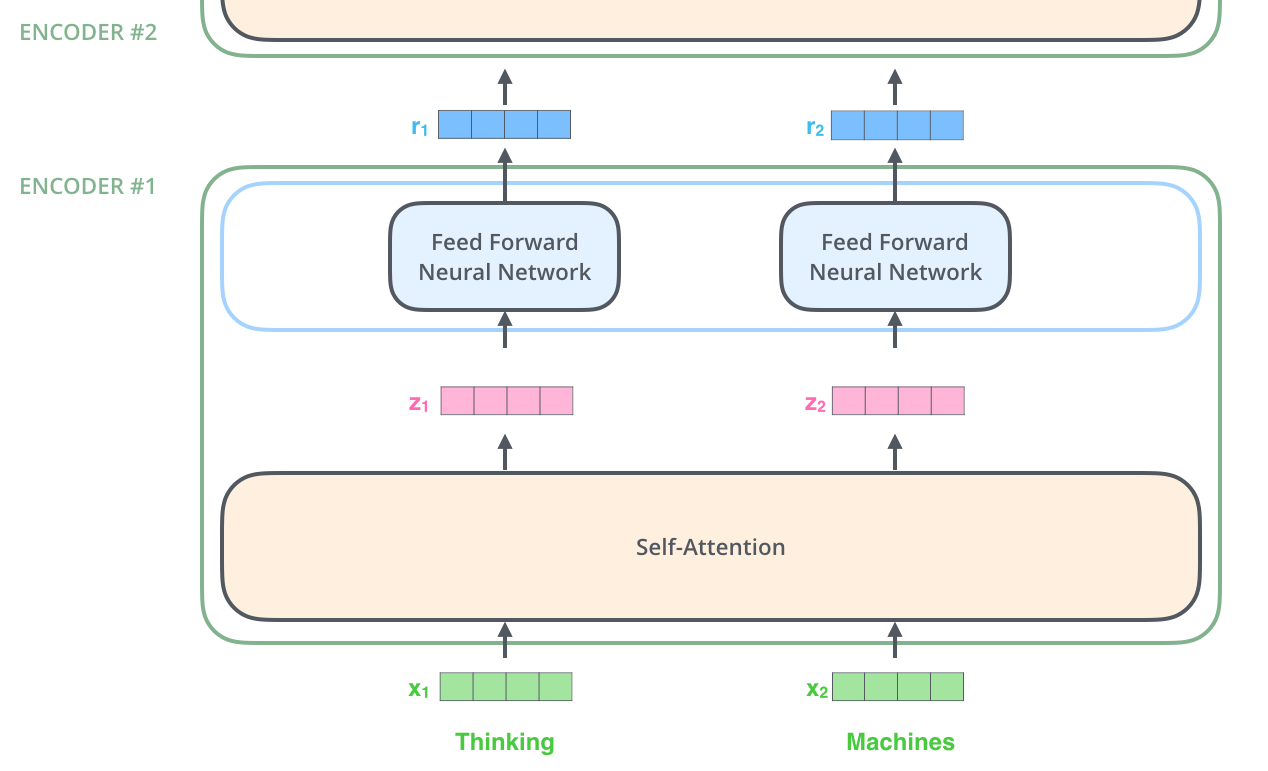

## The Decoder
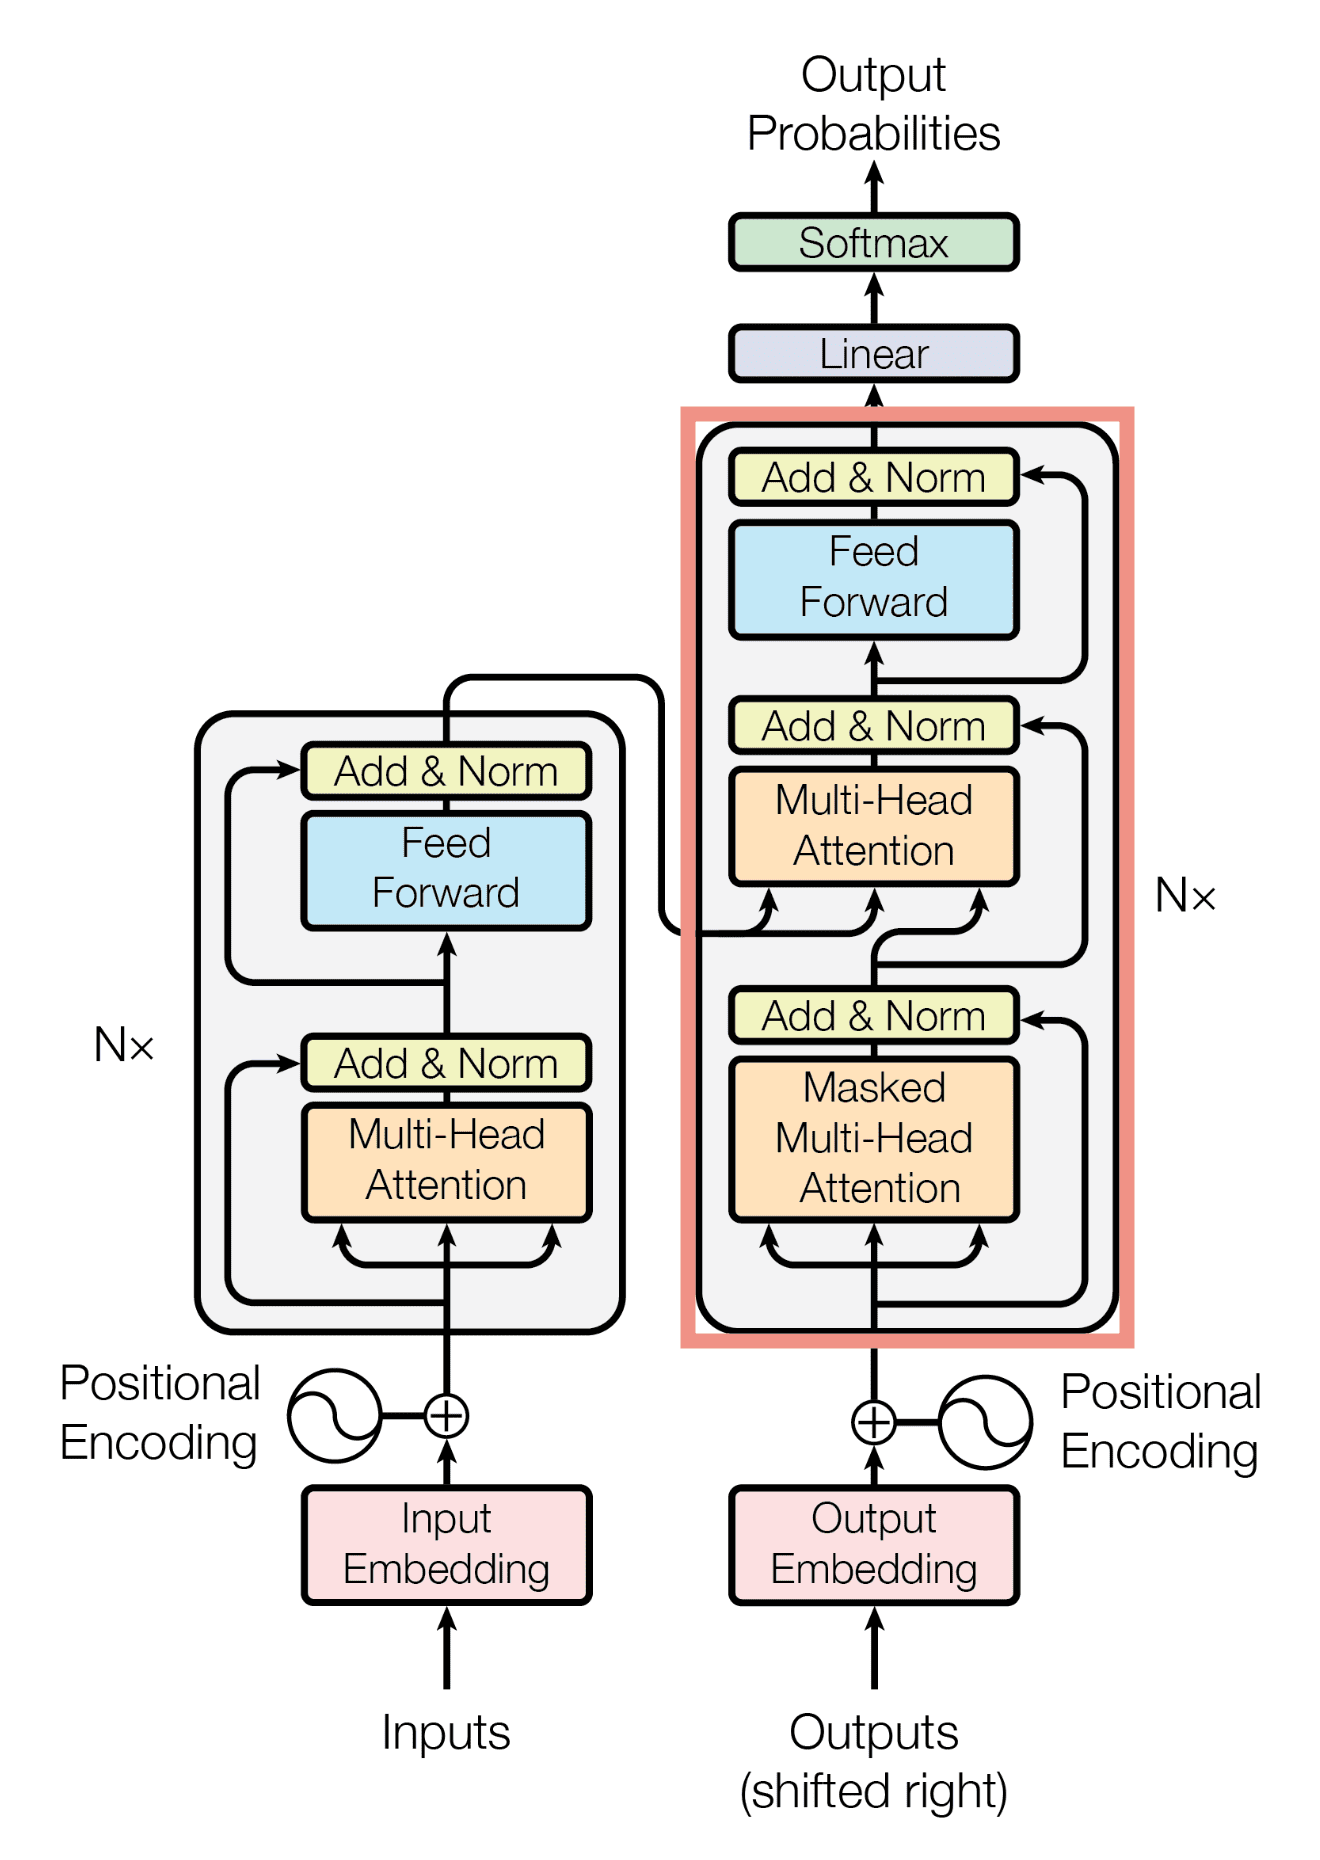

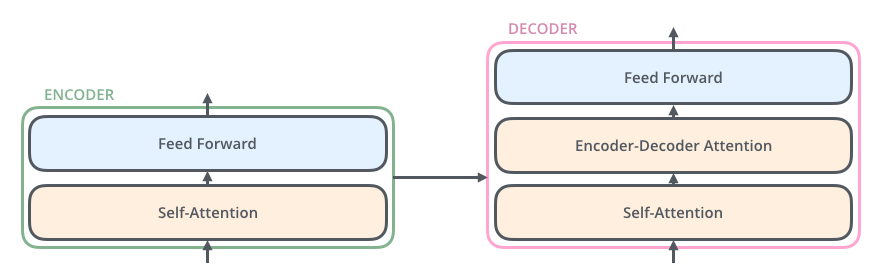

- All encoder blocks are **identical copies**.  
  → Understanding one encoder block means understanding the entire encoder.

### Inside an Encoder Block
- An encoder block consists of:
  - **Multi-Head Self-Attention**
  - **Feed-Forward Neural Network**
  - **Add & Normalize layers**
  - **Residual Connections**
- Input flows through these components step by step, transforming the representation.

### Data Flow
1. Input sentence (or batch of sentences) enters the **first encoder block**.
2. Output from the 1st block becomes input to the 2nd block.
3. This process continues through all 6 encoder blocks.
4. Final encoder output is passed to the **Decoder**.

## Key Idea
- The encoder processes input text through multiple identical layers.
- Each layer refines the representation using **self-attention + feed-forward networks**.
- Residual connections and normalization stabilize training and preserve information.

---

# Transformer Encoder Architecture (Step-by-Step Walkthrough)

We now dive into the **“how” part** of the Transformer encoder.  
To make it concrete, let’s take an example sentence:

**Example sentence:** *How are you*

Although in reality we pass **batches of sentences**, for simplicity, let’s assume our batch has only this one sentence.

---

## 1. Input Block (Pre-processing before entering the Encoder)
Before the input enters the first encoder block, three operations are performed:

### (a) Tokenization
- The sentence *How are you* is broken into tokens:  
  **[How] [are] [you]**

### (b) Text Vectorization (Embeddings)
- Transformers cannot process raw words; words must be converted to numbers.
- Each word is mapped to a **512-dimensional embedding vector**.  
  Example:  
  - *How* → `512-dim vector`  
  - *are* → `512-dim vector`  
  - *you* → `512-dim vector`

### (c) Positional Encoding
- Embeddings alone don’t capture **word order**.  
- Positional encoding adds order information using sinusoidal vectors.  
- Each position also gets a **512-dim positional vector**.
- Final input vectors are formed by adding embedding + positional encoding:  
  - `x1 = embedding(How) + position(1)`  
  - `x2 = embedding(are) + position(2)`  
  - `x3 = embedding(you) + position(3)`

Thus, after preprocessing, we have:  
**x1, x2, x3 → each 512-dimensional**

---

## 2. Multi-Head Attention (Contextual Embeddings)
- Input vectors (**x1, x2, x3**) enter the **multi-head attention block**.  
- Purpose: to make embeddings **context-aware**.

### Why needed?
- A plain embedding cannot distinguish context.  
  Example: *bank* (money bank vs river bank) → same embedding, but different meanings.  
- Self-attention adjusts embeddings by looking at **neighboring words**.  

### Process (simplified):
- Each word vector generates a new contextual vector:  
  - `z1 = context-aware vector of "How"`  
  - `z2 = context-aware vector of "are"`  
  - `z3 = context-aware vector of "you"`  
- Each `z` is still **512-dimensional**, but richer in meaning.

---

## 3. Add & Normalize (Residual Connection + LayerNorm)

### (a) Residual Connection
- The original input vectors (**x1, x2, x3**) are **bypassed** and added to the multi-head attention output (**z1, z2, z3**).  
- New vectors formed:  
  - `z1' = x1 + z1`  
  - `z2' = x2 + z2`  
  - `z3' = x3 + z3`

### (b) Layer Normalization
- Problem: Attention outputs can have values in **unbounded ranges**, making training unstable.  
- Solution: Apply **layer normalization** to stabilize training by scaling vectors into a consistent range.  
- After normalization, we get:  
  - `z1_norm, z2_norm, z3_norm` → all still **512-dimensional**

---

## 4. Why Residual Connections?
- They help in:
  1. **Gradient flow** → prevent vanishing gradients in deep networks.  
  2. **Information preservation** → original input features are not lost during transformations.  
  3. **Better training stability** → models converge faster.

---

## 5. Current State
At this point, after the **first half of the encoder block**, we have:  
- Three **normalized vectors**:  
  **[z1_norm, z2_norm, z3_norm]**  
- Each is still **512-dimensional**.  
- These vectors are now **contextual + normalized**, ready to be passed into the **feed-forward network** in the next stage.

---


# Transformer Encoder – Feed Forward Block

We now continue our journey into the **second half** of the encoder block:  
the **Position-wise Feed Forward Neural Network (FFN)**.

At this point, we already have three normalized vectors from the **Add & Norm step**:  
$$
z1_{\text{norm}},\; z2_{\text{norm}},\; z3_{\text{norm}}
$$
Each is **512-dimensional**.

---

## 1. Feed Forward Network (Architecture)
The FFN in the Transformer encoder is a **two-layer fully connected neural network** applied to each token independently (position-wise).

- **Input layer (not counted):** Takes a 512-dimensional vector.  
- **Layer 1 (Expansion):**
  - Neurons: **2048**
  - Activation: **ReLU**
  - Weights: $(W_1 \in \mathbb{R}^{512 \times 2048}$)  
  - Bias: $(b_1 \in \mathbb{R}^{2048}$)
- **Layer 2 (Projection back):**
  - Neurons: **512**
  - Activation: **Linear**
  - Weights: $(W_2 \in \mathbb{R}^{2048 \times 512}$)  
  - Bias: $(b_2 \in \mathbb{R}^{512}$)

**Computation:**
$$
\text{FFN}(x) = \text{ReLU}(x W_1 + b_1) W_2 + b_2
$$

---

## 2. Input as a Batch Matrix
- We have **3 tokens** (*How, are, you*).  
- Each token = 512-dimensional vector.  
- Together they form a matrix:  
  $$
  Z_{\text{norm}} \in \mathbb{R}^{3 \times 512}
  $$

### Step 1: Expansion
$$
Z_{\text{hidden}} = \text{ReLU}(Z_{\text{norm}} W_1 + b_1)
$$
- Shape: \(3 \times 2048\)  
- Each token’s dimensionality increased from **512 → 2048**.

### Step 2: Projection
$$
Y = Z_{\text{hidden}} W_2 + b_2
$$
- Shape: $(3 \times 512$)  
- Each token is reduced back to **512 dimensions**.

---

## 3. Why Expand and then Shrink Back?
At first glance, it may feel redundant:  
we expand (512 → 2048) and then shrink back (2048 → 512).  

But the key reason is:  
- **ReLU adds non-linearity** in the expanded space.  
- Higher-dimensional transformation allows the network to capture **richer patterns**.  
- Projection back ensures output matches the expected **512-dim size** for compatibility across encoder layers.

Thus, FFN adds **expressive power** while preserving **dimensional consistency**.

---

## 4. Add & Normalize (Again)
After the FFN block:

1. **Residual Connection**
   - Input vectors $(z1_{\text{norm}}, z2_{\text{norm}}, z3_{\text{norm}}$) are bypassed and added to FFN outputs $(y1, y2, y3$).  
   - New vectors:  
     $$
     y1' = y1 + z1_{\text{norm}},\;
     y2' = y2 + z2_{\text{norm}},\;
     y3' = y3 + z3_{\text{norm}}
     $$

2. **Layer Normalization**
   - Applied again to stabilize values.  
   - Final output vectors:  
     $$
     y1_{\text{norm}},\; y2_{\text{norm}},\; y3_{\text{norm}}
     $$

---

## 5. Output of One Encoder Block
- After **Multi-Head Attention + FFN**, the encoder block outputs:  
  $$
  [y1_{\text{norm}},\; y2_{\text{norm}},\; y3_{\text{norm}}]
  $$
- Shape: \(3 \times 512\)  
- This output is then passed as input to the **next encoder block**.

---

## 6. Important Note
- All encoder blocks share the **same architecture**,  
  but **parameters (weights, biases)** are **different** for each block.  
- This allows each block to **learn complementary transformations** while maintaining structural uniformity.

---

**Summary so far:**  
- Input (*How are you*) → Embedding + Positional Encoding → Encoder Block  
- Inside Encoder Block:  
  1. Multi-Head Attention + Add&Norm  
  2. Feed Forward Network (2-layer MLP with ReLU) + Add&Norm  
- Output shape remains constant: **[#tokens × 512]**  
- Repeated across **6 encoder blocks**, final output goes to the **Decoder**.

---


## Common Questions After Studying the Transformer Encoder

While studying the encoder part of the Transformer, a few natural questions may arise. Let’s address three important ones:

---

### 1. Why are **residual connections** used in the encoder?

- **No official explanation:** The original Transformer paper does not explicitly explain why residual connections were used. However, experiments and practical implementations show they are crucial.
- **Stable training:** Residual connections were first introduced in ResNet to stabilize training of very deep networks. They help mitigate the **vanishing gradient problem** by providing alternate gradient flow paths, ensuring updates don’t shrink too much.
- **Preserve original features:** Residual connections allow the model to pass original features forward unchanged.  
  - Example: If multi-head attention fails to produce useful embeddings, the model can still fall back on the original features through the skip path.  
  - This prevents degraded transformations from harming overall performance.
- **Summary:** Residuals both stabilize training in deep networks and safeguard useful feature information.

---

### 2. Why do we use a **Feed-Forward Neural Network (FFN)** after multi-head attention?

- **Linear vs. nonlinear:** Multi-head attention is largely a **linear** operation. To capture **nonlinear patterns** in language, we need an additional feed-forward network with nonlinear activation (like ReLU).
- **Representation power:** The FFN increases the expressive power of the model by applying transformations beyond attention.
- **Research perspective:**  
  - Recent papers suggest that FFNs in Transformers may act as **key-value memories**, storing associations from training data.  
  - Notably, around **two-thirds of Transformer parameters** come from FFN layers, showing their importance despite limited understanding.
- **Summary:** FFNs add nonlinearity, enrich representations, and might serve as memory mechanisms.

---

### 3. Why are there **six encoder blocks** (and not just one)?

- **Deeper understanding of language:** Human language is highly complex. A single encoder block does not provide sufficient representational power to fully capture linguistic dependencies.
- **Stacking layers:** Adding multiple encoder layers creates **deeper representations**, enabling the model to capture hierarchical and abstract patterns in the data.
- **Why six specifically?**  
  - Empirically, six layers gave the best performance in the original Transformer.  
  - However, this number varies across applications (e.g., BERT, GPT, etc., use different depths).
- **Philosophy:** Deep learning leverages depth — stacking more layers creates richer feature hierarchies. The encoder’s multiple layers follow this principle.

---

## Key Takeaways

- **Residual connections** → Stabilize training & preserve original features.  
- **Feed-Forward Networks** → Add nonlinearity & may serve as memory.  
- **Multiple encoder layers** → Provide high representational power needed to understand complex language.  

Together, these design choices make the Transformer encoder both stable and powerful for sequence modeling.


# Transformer Decoder Architecture (Training Perspective)

In the Transformer architecture, the **decoder** is responsible for generating the output sequence using both the previously generated tokens and the encoded representation from the encoder.  

Before diving into the decoder architecture, two important points to note:
1. This explanation is from the **training perspective** (non-autoregressive).  
2. During **inference**, the decoder behaves differently (autoregressive generation), which will be studied separately.

---

<div style="display: flex; justify-content: left;">
    <img src="decoder.png" alt="image1" width="500"/>
    <img src="decoder2.png" alt="image2" width="500"/>
</div>

<div style="display: flex; justify-content: left; margin-top: 10px;">
    <img src="decoder3.png" alt="image3" width="500"/>
    <img src="decoder4.png" alt="image4" width="500"/>
</div>


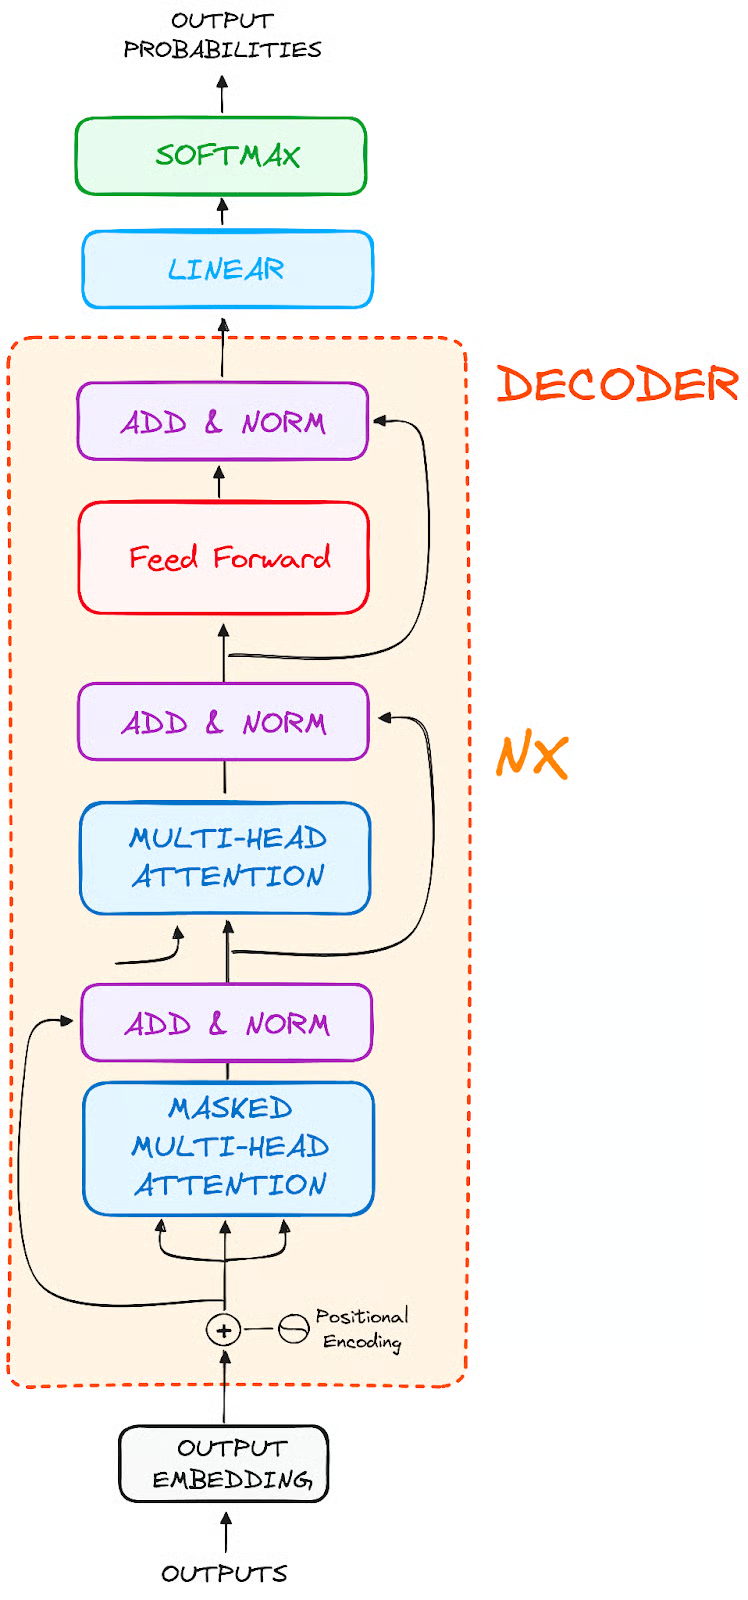

## High-Level Overview

- A **Transformer** can be viewed as a big box with two smaller boxes inside:
  1. **Encoder**: Encodes the input sequence.  
  2. **Decoder**: Decodes the encoded input into the target output sequence.  

- Both encoder and decoder are not single blocks.  
  - The **encoder** consists of **6 identical encoder blocks**.  
  - The **decoder** consists of **6 identical decoder blocks**.  

---

## Components of a Decoder Block

Each **decoder block** has **three sub-blocks** (unlike encoder blocks, which have two):

1. **Masked Multi-Head Self-Attention**
   - Prevents attending to future tokens.
   - Ensures correct autoregressive behavior during training.

2. **Cross-Attention (Encoder-Decoder Attention)**
   - Queries come from the decoder.
   - Keys and values come from the encoder outputs.
   - Allows decoder to connect the source and target sequences.

3. **Feed-Forward Neural Network**
   - Applies two linear transformations with a non-linearity in between.
   - Same as encoder FFN.

Each sub-block is wrapped with:
- **Residual connections (Add)**
- **Layer Normalization (Norm)**

---

## Architecture of the Full Decoder

- The decoder is formed by stacking **6 such decoder blocks** sequentially.  
- Output from each block is passed to the next.  
- After the final (6th) block, the decoder produces a representation that goes into the **output layer (softmax)** to generate the next token probabilities.

---

## Simplified Flow Representation

1. Input (previous target tokens + positional encoding) →  
   **Masked Self-Attention** →  
2. Output of step 1 + Encoder Outputs →  
   **Cross-Attention** →  
3. Output of step 2 →  
   **Feed-Forward Network** →  
4. Pass to next decoder block (repeat 6 times).  

Finally, the last decoder block output → **Output Layer** → predicted tokens.

---

## Key Notes

- **Decoder = 6 stacked blocks** (each with 3 sub-blocks).  
- Training: non-autoregressive (parallelized with masking).  
- Inference: autoregressive (one token at a time).  
- Cross-Attention is the bridge between encoder and decoder.  

This layered structure makes the decoder powerful in capturing both:
- **Target-side dependencies** (via masked self-attention).  
- **Source-target alignment** (via cross-attention).  

# Deep Dive into Transformer Decoder Architecture

We will study the **decoder architecture** in detail, breaking it into **three systematic parts**:

1. **Input Preparation (Decoder Input Block)**  
2. **Internal Processing (Inside a Single Decoder Block)**  
3. **Output Block**  

This breakdown will help us clearly trace how information flows through the decoder during **training**.

---

## Setup for Our Example

- **Task:** Machine Translation (English → Hindi)  
- **Training data (single row for simplicity):**  
  - Input (English): *"We are friends"*  
  - Output (Hindi): *"हम दोस्त हैं"*  

### Encoder’s Role Before Decoder Starts
- The **English sentence** goes into the **encoder**.  
- The encoder produces **contextual embeddings** (also called **encoded embeddings**) for each input token:  
  - Encoded embedding for *We*  
  - Encoded embedding for *are*  
  - Encoded embedding for *friends*  

👉 These embeddings are **already prepared by the encoder** before the decoder begins its work.  

Now, the **decoder’s task** is to take the target side (Hindi sentence during training) and generate the correct sequence step by step.

---

## Decoder Architecture Study – 3 Parts

### 1. Input Block (Preparation)
- The decoder takes the **target sentence (in Hindi)** as input.  
- Before feeding into the decoder, this input is **processed**:  
  1. Each token (*हम*, *दोस्त*, *हैं*) is converted into embeddings.  
  2. **Positional encodings** are added to preserve order.  
  3. These combined embeddings are passed into the **first decoder block**.  

At this stage, the decoder is ready with input representations that will move into the deeper processing layers.

---


# Decoder Input Block – Detailed Explanation

The **Input Block** of the decoder processes the output sentence (target sequence) and converts it into a representation that can be fed into the decoder's first block.

This process can be divided into **four main operations**:

---

## 1. Right Shifting
- Prepares the output sentence (target) for training.  
- Example: Target sentence: "हम दोस्त हैं" (We are friends)  
- Add a special **start token** `[START]` at the beginning.  
- Shifted input sequence: `[START] हम दोस्त हैं]`  
- Purpose: `[START]` signals the decoder where to start generating output during training.

---

## 2. Tokenization
- The sentence is split into **tokens**.  
- Simple tokenization: each word becomes a token.  
- Example: `[START] हम दोस्त हैं]` → Tokens: `[START], हम, दोस्त, हैं`  

---

## 3. Embedding Layer
- Converts tokens into **numerical vectors** that the model can process.  
- In the original Transformer paper, embeddings are **512-dimensional**.  
- Example embeddings:  
  - `[START]` → `e1` (512-dim)  
  - `हम` → `e2` (512-dim)  
  - `दोस्त` → `e3` (512-dim)  
  - `हैं` → `e4` (512-dim)  

---

## 4. Positional Encoding
- Adds **word order information** to embeddings.  
- Each position gets a unique 512-dimensional vector.  
- Example:  
  - Position 1 → vector `p1`  
  - Position 2 → vector `p2`  
  - Position 3 → vector `p3`  
  - Position 4 → vector `p4`  

---

## Final Input Vectors
- Add embedding vector + positional vector → Final input vector  
- Example:  
  - `x1 = e1 + p1`  
  - `x2 = e2 + p2`  
  - `x3 = e3 + p3`  
  - `x4 = e4 + p4`  

**Note:** These final vectors (`x1, x2, x3, x4`) are what get fed into the **first block of the decoder**.

---

**Summary of Steps:**
1. **Right shift** → Add `[START]` token  
2. **Tokenization** → Convert sentence into tokens  
3. **Embedding** → Convert tokens into 512-dimensional vectors  
4. **Positional Encoding** → Add word order information  
5. **Final input vectors** → Ready to enter decoder’s first block


# Decoder First Block – Step-by-Step Explanation

The **first decoder block** consists of **three main operations**:

1. **Masked Multi-Head Self-Attention**  
2. **Cross-Attention (Encoder-Decoder Attention)**  
3. **Feed Forward Neural Network**

We’ll go through each step in order.

---

## 1. Masked Multi-Head Self-Attention

- **Input vectors:** `x1, x2, x3, x4` (from the decoder input block)  
- **Process:** Each token attends to **all previous tokens**, but **not future tokens** (masking).  
  - Generating `z1` considers only `x1`  
  - Generating `z2` considers `x1, x2`  
  - Generating `z3` considers `x1, x2, x3`  
  - Generating `z4` considers `x1, x2, x3, x4`  

- **Output:** Contextual embeddings `z1, z2, z3, z4`  

- **Residual Connection + Layer Normalization:**  
  - Add original input vectors (`x1, x2, x3, x4`) to attention output (`z1, z2, z3, z4`) → `z1' = z1 + x1` and so on  
  - Apply **layer normalization** to stabilize training and keep values in a small range  
  - **Result:** `z1_norm, z2_norm, z3_norm, z4_norm`  

---

## 2. Cross-Attention (Encoder-Decoder Attention)

- **Purpose:** Align **output tokens** (decoder) with **input tokens** (encoder).  
- **Inputs:**  
  - **Queries (Q):** from previous masked self-attention (`z1_norm, z2_norm, ...`)  
  - **Keys & Values (K, V):** from encoder output (`encoder_embeddings`)  

- **Process:**  
  - Each output token attends to **all input tokens** to find similarities.  
  - Similar to a regular multi-head attention block but with **two sequences**: input and output.  

- **Output:** Contextual embeddings for each output token:  
  - `jc1, jc2, jc3, jc4` (where `c` = cross-attention output)  

- **Residual Connection + Layer Normalization:**  
  - Add previous step’s output (`z1_norm, z2_norm, ...`) to cross-attention output (`jc1, jc2, ...`)  
  - Apply **layer normalization** → `jc1_norm, jc2_norm, jc3_norm, jc4_norm`  

---

## 3. Feed Forward Neural Network (To be discussed next)

- After cross-attention, the embeddings are passed to a **position-wise feed-forward network**.  
- Further transformation happens here before moving to the next decoder block.  

---

**Summary of First Decoder Block:**

1. **Masked Self-Attention:** Contextualizes each token w.r.t previous tokens → residual → layer norm  
2. **Cross-Attention:** Aligns decoder tokens with encoder outputs → residual → layer norm  
3. **Feed Forward:** Final transformation of embeddings  

**Key Takeaways:**

- Masking prevents attending to future tokens during training  
- Cross-attention enables interaction between input and output sequences  
- Residual connections and layer normalization stabilize training and maintain gradient flow  
- Output of this block serves as input to the **next decoder block**  



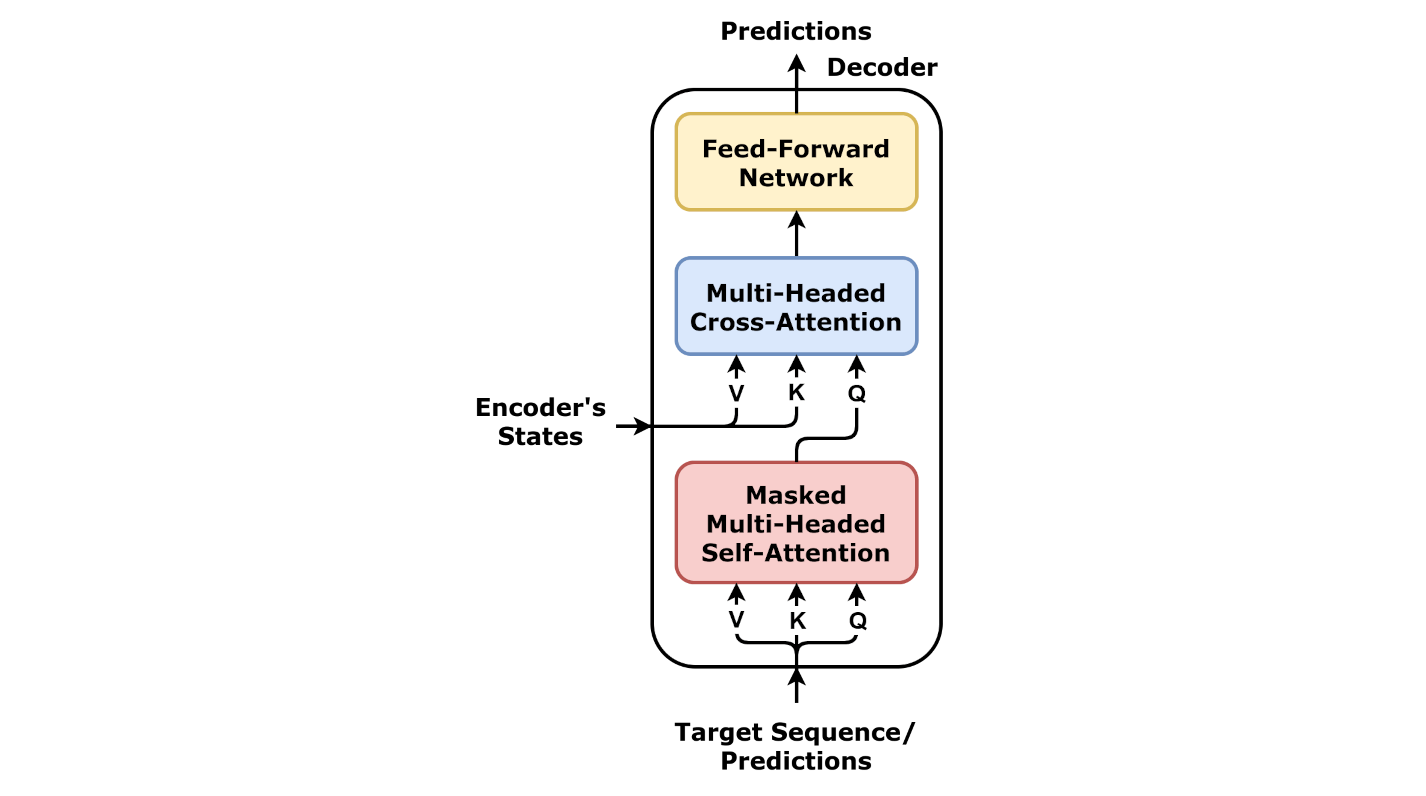

# Decoder First Block – Feed Forward Layer

After **cross-attention**, the embeddings pass through a **Feed-Forward Neural Network (FFN)**.  
This FFN has **exactly the same architecture as the encoder’s FFN**:

---

## FFN Architecture

1. **First Layer:**  
   - Fully connected layer with **2048 neurons**  
   - Activation function: **ReLU**  
   - Input dimension: **512** → Output dimension: **2048**  
   - Parameters:  
     - Weight matrix `W1` of shape 512 × 2048  
     - Bias vector `b1` of size 2048  

2. **Second Layer:**  
   - Fully connected layer with **512 neurons**  
   - Activation function: **Linear**  
   - Input dimension: **2048** → Output dimension: **512**  
   - Parameters:  
     - Weight matrix `W2` of shape 2048 × 512  
     - Bias vector `b2` of size 512  

---

## Process Step-by-Step

- **Input:** A batch of vectors from cross-attention: `jc1_norm, jc2_norm, jc3_norm, jc4_norm` (shape 4 × 512)  
- **Step 1: First Layer Transformation**  
  - Multiply input matrix with `W1` → 4 × 2048  
  - Add bias `b1` → still 4 × 2048  
  - Apply **ReLU activation** → introduces non-linearity  

- **Step 2: Second Layer Transformation**  
  - Multiply result with `W2` → 4 × 512  
  - Add bias `b2` → still 4 × 512  

- **Output:** 4 vectors of dimension 512 each (`y1, y2, y3, y4`)  

---

## Residual Connection + Layer Normalization

- Add **input of FFN** (from cross-attention: `jc1_norm, jc2_norm, ...`) to FFN output → `y1' = y1 + jc1_norm` and so on  
- Apply **layer normalization** → stabilizes training and maintains consistent vector ranges  
- **Final Output of First Decoder Block:**  
  - `y1_norm, y2_norm, y3_norm, y4_norm` (4 vectors, each 512-dimensional)  

---

**Key Takeaways:**

1. FFN is **position-wise**, applied to each token vector independently.  
2. Non-linearity (ReLU) allows capturing complex patterns.  
3. Residual connections + layer normalization keep training stable.  
4. Output vectors are ready to feed into the **next decoder block**.  



# Full Decoder Stack – Passing Through All Six Blocks

As you know, a transformer does not have just **one decoder block** — it has **six decoder blocks** stacked sequentially.

---

## Step-by-Step Flow

1. **Output from First Decoder Block:**  
   - After the first block, we get the normalized output vectors:  
     `y1_norm, y2_norm, y3_norm, y4_norm` (each 512-dimensional)  

2. **Passing to the Second Decoder Block:**  
   - These output vectors are sent directly as input to the **second decoder block**.  
   - The second block performs **exactly the same operations** as the first:  
     1. Masked Multi-Head Attention → Add & Norm  
     2. Cross-Attention → Add & Norm  
     3. Feed-Forward Network → Add & Norm  
   - The **only difference** is that the **parameters (weights and biases) are different** for this block.  

3. **Subsequent Decoder Blocks (3 → 6):**  
   - The output of block 2 becomes the input to block 3.  
   - This process continues sequentially through **all six decoder blocks**.  
   - Each block repeats the same operations:  
     - Masked Multi-Head Attention → Add & Norm  
     - Cross-Attention → Add & Norm  
     - Feed-Forward → Add & Norm  
   - Each block has its **own independent parameters**.

4. **Final Decoder Block (Block 6):**  
   - After the sixth decoder block, we obtain the **final output vectors**:  
     `yf1_norm, yf2_norm, yf3_norm, yf4_norm`  
   - Here `f` stands for **final**.  
   - These vectors represent the fully processed embeddings for each token in the output sequence.  

---

## Key Points

- **All six decoder blocks have the same architecture**, but **different learned parameters**.  
- **Residual connections + layer normalization** are applied in every block to ensure stable training.  
- The **final output vectors from the sixth block** are then sent to the **output layer** for generating the actual tokens.  

This sets the stage for the **last part of the decoder architecture: the output block**, where these final vectors are converted into predicted words in the output sequence.


# Decoder Output Block – Converting Vectors to Words

Now comes the most important and interesting part of the architecture: the **output block**.  

At this stage, we have already passed through **all six decoder blocks**, and we have our **final normalized vectors**:

`yf1_norm`, `yf2_norm`, `yf3_norm`, `yf4_norm`


Each vector corresponds to a token in the output sequence (for example, a Hindi sentence).

---

## Architecture of the Output Block

The output block consists of **two main components**:

1. **Linear Layer**
2. **Softmax Layer**

This is very similar to the final output layer of a feed-forward neural network.

### Linear Layer

- Input: Each vector from the decoder (`512-dimensional` for our example)  
- Number of neurons: `V`, which equals the **vocabulary size** of the target language (Hindi in this case)  
- For example, if there are 10,000 unique Hindi words in your dataset, then `V = 10,000`.  

**Neuron mapping:**  
- Neuron 1 → first word in vocabulary (`मैं`)  
- Neuron 2 → second word (`हूँ`)  
- Neuron 3 → third word (`हम`)  
- … and so on for all 10,000 words  

**Weights and Biases:**  
- Weight matrix: `512 x V` → 512 x 10,000  
- Bias vector: length `V` → 10,000  

**Operation:**  
For a single token vector `yf1_norm` (1 x 512):

$$
\text{output} = yf1\_norm \cdot W3 + b
$$



- Result: 1 x 10,000 vector, one value per vocabulary word.  
- Each value is an unnormalized score for that word.

---

### Softmax Layer

- Softmax converts the unnormalized scores into a **probability distribution** over the vocabulary.  
- Formula ensures that the sum of all probabilities = 1.  
- Example: if the token corresponds to “दोस्त”, the probability for “दोस्त” should be the highest.  


$$
\text{probabilities} = \text{softmax}(\text{output})
$$





- Now we have the predicted probability for each vocabulary word for that token.  
- This is repeated for **all tokens** in parallel (or sequentially, depending on inference).  

---

## Summary of the Decoder Pipeline

1. **Input Block:**  
   - Right-shift tokens, tokenize, embedding, positional encoding → x1, x2, …  

2. **Decoder Stack (6 Blocks):**  
   - Masked Multi-Head Attention → Add & Norm  
   - Cross-Attention → Add & Norm  
   - Feed-Forward → Add & Norm  
   - Each block has **its own parameters**  

3. **Output Block:**  
   - Linear layer (`512 → vocab size`)  
   - Softmax → probability distribution for each token  

This gives the final probabilities for each token in the output sequence. During **training**, these probabilities are used to calculate the loss against the actual target words.  

---

### Key Notes

- Each decoder block preserves **512-dimensional vectors** but transforms them to include richer contextual and non-linear information.  
- Residual connections and layer normalization ensure **stable training**.  
- The output layer converts vector embeddings into **actual word predictions** using the vocabulary mapping.

---

In the next step (inference), the decoder works **autoregressively**:

- Only the predicted tokens so far are fed as input for the next token prediction.  
- The encoder outputs remain the same.  

This allows the transformer to generate one token at a time until the full sentence is produced.


## Transformer Inference (Prediction Phase)

Up to this point, we have studied the complete **Transformer architecture** focusing on its components and training behavior. However, one important aspect is still left: **how the Transformer behaves during inference (prediction time).**

### Encoder Behavior
- The **encoder** behaves **exactly the same** during both training and inference.  
- Steps remain unchanged:
  - Tokenization → Embedding → Positional Encoding  
  - Multi-Head Attention → Add & Norm → Feed Forward → Add & Norm  
- This sequence is repeated across **6 encoder blocks**, producing context-rich vectors for each input token.  
- For example, if the English input sentence is:  


**We are friends**

- Each token ("We", "are", "friends") is converted into embeddings with positional encodings.  
- Through 6 encoder layers, context is captured.  
- Finally, each token gets a **context vector** (e.g., `C_we`, `C_are`, `C_friends`) that represents both the word and its relationship with other words.  

### Decoder Behavior (Key Difference)
The **decoder** behaves differently in training and inference:

- **During Training**:
- The complete output sentence (Hindi translation in our case) is already available.  
- Hence, all target tokens can be passed into the decoder **at once**.  
- This is known as **Non-Autoregressive decoding**.

- **During Inference (Prediction)**:
- The output sentence is **unknown** and must be generated token-by-token.  
- The decoder works in an **Autoregressive manner**:
  1. Start with a special `<START>` token.
  2. Predict the **first word** using encoder outputs + masked attention.  
  3. Feed this predicted word back into the decoder for the **next step**.  
  4. Continue generating words one by one until an `<END>` token is produced or a maximum length is reached.  

### Example: English → Hindi Translation
- Input: `"We are friends"`  
- Encoder generates context vectors for `"We"`, `"are"`, and `"friends"`.  
- Decoder starts with `<START>`:
- At **Step 1**, it predicts `"हम"` (hum).  
- At **Step 2**, decoder uses `<START> + हम` to predict `"दोस्त"` (dost).  
- At **Step 3**, it predicts `"हैं"` (hain).  
- At **Step 4**, decoder outputs `<END>` to stop.  
- Final translation: `"हम दोस्त हैं"`  

---

### Summary
- **Encoder**: Same during training and inference.  
- **Decoder**:
- **Training** → Non-Autoregressive (parallel word prediction).  
- **Inference** → Autoregressive (sequential word prediction).  
- This difference ensures that the model can both **learn efficiently during training** and **generate meaningful translations during prediction**.


## Decoder in Inference Stage (Step-by-Step Walkthrough)

During **inference**, the decoder behaves differently compared to training.  
- **Training** → Non-Autoregressive (all target tokens available, processed in parallel).  
- **Inference** → Autoregressive (tokens generated one by one, step by step).  

At this stage, the encoder has already processed the input sentence and produced **context vectors**. Now the decoder begins generating the output sequence.

---

### Step 1: Starting with SOS Token
- Decoding begins with a special token called **SOS (Start of Sentence)**.  
- This tells the decoder that it should start producing the first output word.

#### Processing SOS token:
1. **Embedding Layer**  
   - Converts the SOS token into a **512-dimensional embedding vector**.  

2. **Positional Encoding**  
   - Even though there is only one token, positional encoding is always added.  
   - Final input vector after embedding + positional encoding is called **x₁**.  

3. **Input to Decoder**  
   - This vector `x₁` now enters the first decoder block.  

---

### Step 2: Masked Self-Attention Block
- The first component inside the decoder is **Masked Multi-Head Self-Attention**.  
- For explanation, consider only a **single head** (though in practice it is multi-head).

1. Compute the three projection vectors:
   - **Query (Q) = x₁ W_Q**  
   - **Key (K) = x₁ W_K**  
   - **Value (V) = x₁ W_V**

2. Since there is only **one token**, the query interacts with itself:  
   - Attention Score = Softmax( (Q · Kᵀ) / √d )  
   - This gives a scalar attention weight.

3. Multiply this score with the value vector V:  
   - `z₁ = Attention Score × V`  
   - Result is again a **512-dimensional vector**.  

4. **Residual Connection + Layer Norm**  
   - Add `z₁` with the original input `x₁` through a skip connection.  
   - Normalize using **LayerNorm** to produce **z₁_norm**.  

So, after masked self-attention, we have `z₁_norm`.

---

### Step 3: Cross-Attention Block (Preview)
- Next, the vector `z₁_norm` goes into the **Cross-Attention block**.  
- This block is crucial because it allows the decoder to **interact with encoder outputs (context vectors)**.  
- Here, queries come from the decoder (`z₁_norm`), while keys and values come from the encoder outputs.  

---

### Where We Are Now
- We started with the **SOS token**.  
- Embedded + positional encoded → `x₁`.  
- Passed through **Masked Self-Attention** → `z₁_norm`.  
- Next step → **Cross-Attention**, where decoder aligns its current state with encoder’s context vectors.

---

**NOTE** This process will repeat for each step:
- Step 1 → predict first word.  
- Step 2 → use `<SOS> + first predicted word` to generate the second word.  
- Step 3 → extend further until `<END>` token appears.  


### Decoder: Step-by-Step Processing (Inference Phase)

The **decoder** in the Transformer behaves differently during **training** and **inference**.  
- In **training**, the entire target sequence is known, and outputs are computed in parallel.  
- In **inference**, decoding happens **step by step** (auto-regressive), generating one word at a time until the full sentence is formed.

---

#### 1. Initial Setup
- At the start of inference, we already have the **encoder outputs** (contextual vectors).  
- The decoder begins by receiving a **special token** called `<SOS>` (Start of Sentence).  
- This token signals the decoder to start generating words.

---

#### 2. Input Processing
1. `<SOS>` is first **vectorized** using the **embedding layer**, producing a 512-dimensional embedding vector.  
2. **Positional Encoding** is added to this embedding (even though there’s only one token at this step).  
3. The final input vector (denoted as `x1`) enters the first decoder block.

---

#### 3. Inside a Decoder Block
Each decoder block has **three main sub-layers**:
1. **Masked Self-Attention**
2. **Cross-Attention**
3. **Feed Forward Network (FFN)**  
   + Each sub-layer is followed by **Add & Norm** operations.

---

##### (a) Masked Self-Attention
- Input vector `x1` is transformed into:
  - Query (Q), Key (K), and Value (V) vectors.
- Attention scores are computed as `Q • Kᵀ`, scaled, and passed through **softmax**.  
- These scores decide how much each token should attend to previous tokens.  
- Since we only have `<SOS>` at this point, it only attends to itself.  
- The weighted sum of values produces vector `z1`.  
- After **residual connection + normalization**, we get `z1_norm`.

---

##### (b) Cross-Attention
- Queries are taken from the decoder (`z1_norm`).  
- Keys and Values are taken from the **encoder outputs** (context sequence, e.g., "We are friends").  
- Cross-attention helps the decoder focus on relevant encoder tokens.  
- Dot-products of decoder queries with encoder keys produce attention weights:
  - Example: `<SOS>` compared with "We", "are", "friends".  
- The weighted sum of encoder values gives a new vector `z_c`.  
- After **residual + normalization**, we obtain `z_c_norm`.

---

##### (c) Feed Forward Network (FFN)
- Input: `z_c_norm`  
- The FFN has:
  - One hidden layer (2048 units, ReLU activation).  
  - An output layer (512 units, linear).  
- This adds non-linearity and feature transformation.  
- The output is passed through **Add & Norm**, producing `y1_norm`.

---

#### 4. Multiple Decoder Blocks
- The above process (Masked Attention → Cross Attention → FFN) is repeated **across 6 decoder blocks**.  
- Each block has the same operations but different learned parameters.  
- The final block produces a **final normalized vector** `y_f1_norm`.

---

#### 5. Output Layer
- The final decoder output vector (`y_f1_norm`) is passed to:
  1. **Linear Layer**: Projects 512-dim → Vocabulary size (V).  
  2. **Softmax Layer**: Converts raw scores into probabilities across all vocabulary words.  
- Example: For a Hindi dataset, probabilities might be assigned to each unique Hindi word.  
- The word with the **highest probability** is selected as the decoder’s output for this step.  
- Suppose the chosen word is **"हम" ("we")**. This becomes the **first generated word**.

---

#### 6. Auto-Regressive Decoding
- The decoder now moves to the **next step**.  
- The previously generated word (`हम`) is fed back as input, along with `<SOS>`.  
- The process repeats (embedding → positional encoding → decoder blocks → softmax).  
- This continues **step by step**, until an `<EOS>` (End of Sentence) token is produced.

---

Thus, the decoder gradually builds the translated sentence **one word at a time**, attending both to past predictions and the encoder outputs.


### Decoder: Second Time Step (Inference)

In the **second time step**, the decoder input is not just `<SOS>` but also the previously predicted word.  
- **First time step input** → `<SOS>` only  
- **Second time step input** → `<SOS>` + `"हम"`  
- At every step, the decoder reuses its predicted outputs as inputs.

---

#### 1. Input Representation
1. Both tokens (`<SOS>`, `"हम"`) pass through the **embedding layer**.  
   - `<SOS>` already has an embedding.  
   - `"हम"` gets converted into its embedding vector.  
2. **Positional encodings** are added:
   - Position 0 → `<SOS>`  
   - Position 1 → `"हम"`  
3. Final inputs to the decoder block:
   - `x1` = `<SOS>` embedding + position encoding  
   - `x2` = `"हम"` embedding + position encoding  

---

#### 2. Masked Self-Attention (Step 2)
- For each token (`x1`, `x2`), we compute:
  - Query (Q), Key (K), Value (V) vectors.  
- Now we have:
  - Q1, K1, V1 → for `<SOS>`  
  - Q2, K2, V2 → for `"हम"`

**Attention score matrix:**  

| Query ↓ / Key → | `<SOS>` | `"हम"` |
|-----------------|---------|--------|
| `<SOS>` (Q1)    | sim(Q1,K1) | sim(Q1,K2) |
| `"हम"` (Q2)     | sim(Q2,K1) | sim(Q2,K2) |

- These similarity scores are scaled (by √d) and passed through **softmax**.  
- **Masking rule:**  
  - `<SOS>` cannot see `"हम"` (future token).  
  - `"हम"` can see both `<SOS>` and itself.  

Thus:  
- For `<SOS>`, only its self-similarity matters.  
- For `"हम"`, attention considers both `<SOS>` and `"हम"`.

**Important:**  
Masking is applied even during **inference**.  
- Why? Because masking was applied during **training**.  
- If we don’t mask during inference, there would be a **train–test mismatch**, leading to poor predictions.

**Outputs after masked self-attention:**  
- `z1`, `z2` (512-dim vectors)  
- After residual connection + normalization → `z1_norm`, `z2_norm`

---

#### 3. Cross-Attention (Step 2)
- Queries come from decoder side (`z1_norm`, `z2_norm`).  
- Keys and Values come from the **encoder outputs** (e.g., contextual embeddings of "We are friends").  
- Each decoder token now attends to the entire encoder sequence.

For example:  
- `<SOS>` query checks similarity with encoder outputs of "We", "are", "friends".  
- `"हम"` query also checks similarity with "We", "are", "friends".  

- The weighted sums produce new vectors: `z1_c`, `z2_c`.  
- After residual connection + normalization → `z1_c_norm`, `z2_c_norm`.

---

#### 4. Feed Forward Network (Step 2)
- Each vector (`z1_c_norm`, `z2_c_norm`) passes through the **Feed Forward Network (FFN)**:
  - Hidden layer: 2048 units, ReLU activation  
  - Output layer: 512 units, Linear activation  
- Produces transformed outputs: `y1`, `y2`  
- After residual + normalization → `y1_norm`, `y2_norm`

---

#### 5. Repeated Decoder Blocks
- Just like before, these outputs pass sequentially through **6 decoder blocks**.  
- Each block repeats the same operations (masked attention → cross attention → FFN).  
- Final outputs after the 6th block: `y_f1_norm`, `y_f2_norm`.

---

#### 6. Output Layer (Step 2)
- Final vectors are projected into vocabulary space (via linear + softmax).  
- Probability distribution is generated for each vocabulary word.  
- The most probable word is selected as the **second predicted word**.  

 Now we have:  
- Step 1 output = `"हम"`  
- Step 2 output = (next predicted word, say `"दोस्त"` → "friend")  

Thus, decoding continues step by step, with each new predicted word added to the input sequence for the next step.


# Transformer Decoder – Sequential Processing and Inference

## Multi-Block Decoder Structure
- The Transformer has **6 decoder blocks** stacked sequentially.
- Each block performs the same set of operations:
  1. Masked Multi-Head Self-Attention  
  2. Add & Layer Normalization  
  3. Cross-Attention (with encoder outputs)  
  4. Add & Layer Normalization  
  5. Feed-Forward Network (FFN)  
  6. Add & Layer Normalization  

- The **only difference** between blocks is the **parameters (weights)**, but the operations remain identical.
- Output of Decoder Block 1 is passed into Decoder Block 2, then into Block 3, and so on until Block 6.
- After the final block, we obtain the **final normalized output vectors**:  
  $$
  y_{f1}^{norm}, y_{f2}^{norm}, \dots
  $$

---

## Decoder During Inference (Auto-Regressive Generation)

### Step 1: First Token Input
- At **time step 1**, the decoder input is only the **Start of Sequence (SOS)** token.  
- After passing through all 6 decoder blocks, the model predicts the **first word** (e.g., "Hum").  

---

### Step 2: Adding the Next Token
- At **time step 2**, the decoder input becomes:
  $$
  [SOS, Hum]
  $$
- The embedding layer generates embeddings for both tokens.  
- Positional encodings are added (position 0 for SOS, position 1 for Hum).  
- These become the **two input vectors**:  
  $$
  x_1, x_2
  $$

---

### Step 3: Masked Multi-Head Attention
- For each token, we compute **Query (Q), Key (K), and Value (V)** vectors.  
- Attention scores are computed as dot products between queries and keys.  
- Masking ensures that a token **cannot attend to future tokens**:
  - SOS can only attend to itself.  
  - "Hum" can attend to SOS and itself.  
- This produces attention outputs $$
  z_1, z_2
  $$.
- Add & Norm is applied:
  $$
  z_1^{norm}, z_2^{norm}
  $$

---

### Step 4: Cross-Attention with Encoder Outputs
- Encoder outputs provide Keys and Values.  
- Decoder vectors ($(z_1^{norm}, z_2^{norm}$)) act as Queries.  
- Attention is computed between decoder queries and encoder key-value pairs.  
- Outputs are normalized:
  $$
  z_{c1}^{norm}, z_{c2}^{norm}
  $$

---

### Step 5: Feed Forward Network
- Each vector passes through a **2-layer feed-forward neural network**:
  - Linear → ReLU → Linear  
  - Dimensions: 512 → 2048 → 512  
- Outputs after Add & Norm:
  $$
  y_1^{norm}, y_2^{norm}
  $$

---

## Auto-Regressive Output Mechanism
- Even though multiple vectors ($(y_1^{norm}, y_2^{norm}$)) exist, at **each time step only the last token’s vector is used** for prediction.  
  - At Step 1: Use SOS → predict "Hum"  
  - At Step 2: Use vector for "Hum" → predict "Dost"  
- The earlier vectors (like SOS’s) are ignored after their token has already been generated.  

---

## Step 3 and Beyond
- At **time step 3**, input = `[SOS, Hum, Dost]`.  
- The same process repeats, but now with **three vectors** at every block.  
- Only the **last vector ("Dost")** contributes to the next word prediction.  
- This continues until the decoder outputs the **End of Sequence (EOS)** token, signaling that generation should stop.

---

## Key Points to Remember
1. **Training vs Inference**:
   - Training: Decoder works **non-autoregressively** (all tokens together).  
   - Inference: Decoder works **autoregressively** (one token at a time).  

2. **Masking**:
   - Applied during both training and inference.  
   - Prevents tokens from attending to **future tokens**.  

3. **Token Growth**:
   - At each time step, the decoder input increases by **one new token**.  
   - Step 1: 1 token → Step 2: 2 tokens → Step 3: 3 tokens → and so on.  

4. **Final Prediction**:
   - At each step, only the **last token’s vector** is passed to the linear + softmax layer.  
   - This ensures exactly **one token output per time step**.  

---

## Summary
- The encoder remains constant once computed.  
- The decoder runs step-by-step, adding one token each time.  
- Masked self-attention ensures causal (left-to-right) prediction.  
- Cross-attention links decoder tokens to encoder context.  
- Feed-forward and normalization layers refine the outputs.  
- The process stops once the EOS token is generated.  

This is how the **Transformer Decoder works during inference**, following its **auto-regressive property**.
